# D-1 PERCOBAAN HISTOGRAM

In [2]:
import cv2 as cv
# from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt 
import numpy as np
import math
import os
import glob

Membuat histogram citra seperti berdasarkan flowchart di bawah ini : (Gunakan gambar lena.jpg)

<BarContainer object of 256 artists>

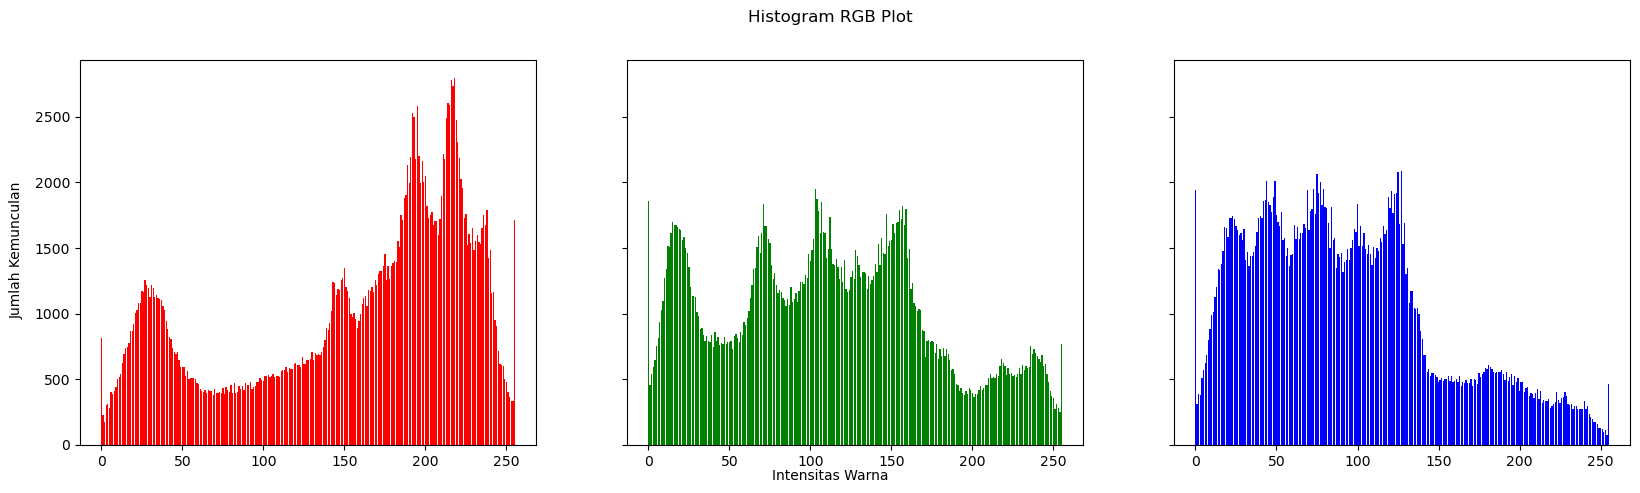

In [3]:
img = img = cv.imread('../images/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0, height):
    for x in range(0, width):
        red[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]] += 1
        
names = np.arange(256)
fig, axs = plt.subplots(1, 3 , figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB Plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')


## PERTANYAAN PRAKTIKUM D1

### 1. Buatlah histogram citra yang sama akan tetapi menggunakan library yang dimiliki oleh NumPy yaitu “histogram”. Bandingkan hasilnya. Apakah output muncul sama?

<BarContainer object of 256 artists>

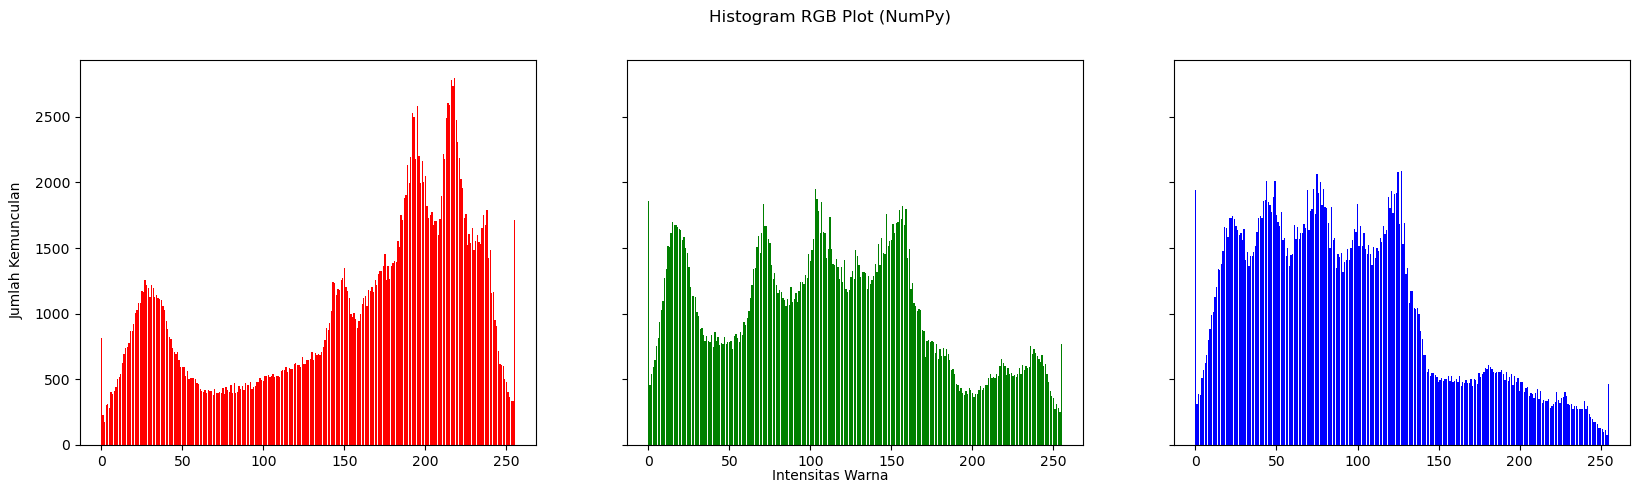

In [4]:
img2 = img2 = cv.imread('../images/lena.jpg')
img2 = cv.cvtColor(img2, cv.COLOR_BGR2RGB)

red2 = img2[:,:,0].ravel()
green2 = img2[:,:,1].ravel()
blue2 = img2[:,:,2].ravel()

hist_red, bins_red = np.histogram(red2, bins=256, range=(0,256))
hist_green, bins_green = np.histogram(green2, bins=256, range=(0,256))
hist_blue, bins_blue = np.histogram(blue2, bins=256, range=(0,256))

names = np.arange(256)
fig, axs = plt.subplots(1, 3 , figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB Plot (NumPy)')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, hist_red, color='red')
axs[1].bar(names, hist_green, color='green')
axs[2].bar(names, hist_blue, color='blue')

### 2. Buatlah histogram dengan menggunakan dengan menggunakan image KTM lama.jpg. Analisis distribusi intensitas dari histogram yang dihasilkan apakah gambar cenderung gelap, terang, atau kontras rendah.

<BarContainer object of 256 artists>

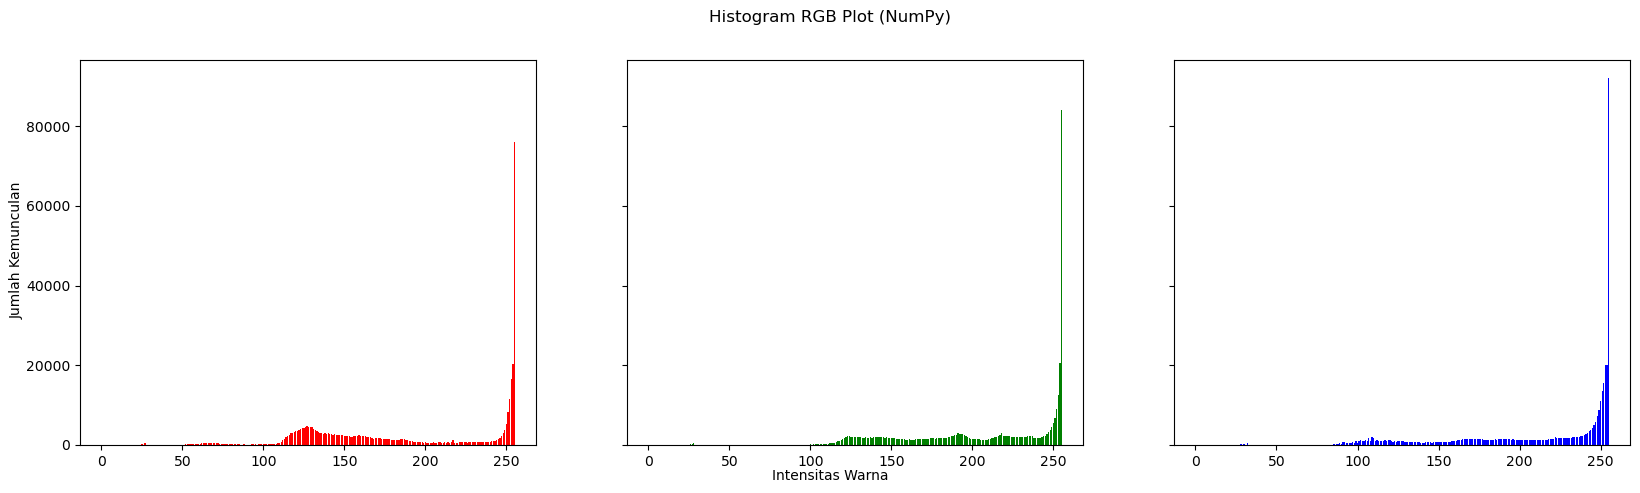

In [8]:
img3 = img3 = cv.imread('../images/KTM_lama.jpg')
img3 = cv.cvtColor(img3, cv.COLOR_BGR2RGB)

red2 = img3[:,:,0].ravel()
green2 = img3[:,:,1].ravel()
blue2 = img3[:,:,2].ravel()

hist_red, bins_red = np.histogram(red2, bins=256, range=(0,256))
hist_green, bins_green = np.histogram(green2, bins=256, range=(0,256))
hist_blue, bins_blue = np.histogram(blue2, bins=256, range=(0,256))

names = np.arange(256)
fig, axs = plt.subplots(1, 3 , figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB Plot (NumPy)')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, hist_red, color='red')
axs[1].bar(names, hist_green, color='green')
axs[2].bar(names, hist_blue, color='blue')

Penjelasan: Gambar KTM Lama.jpg cenderung terang dikarenakan pada histogram tinggi pada nilai sekitar 255, dan gambar tersebut termasuk kontras rendah dikarenakan persebaran histogramnya tidak merata.

# D-2 PERCOBAAN HISTOGRAM EQUALIZATION

### 1. Buatlah histogram citra seperti output histogram equalization dan juga tampilan gambar sebelum dan sesudah proses histogram equalization berikut berdasarkan flowchart di bawah ini : (Gunakan gambar lena_lc.jpg)

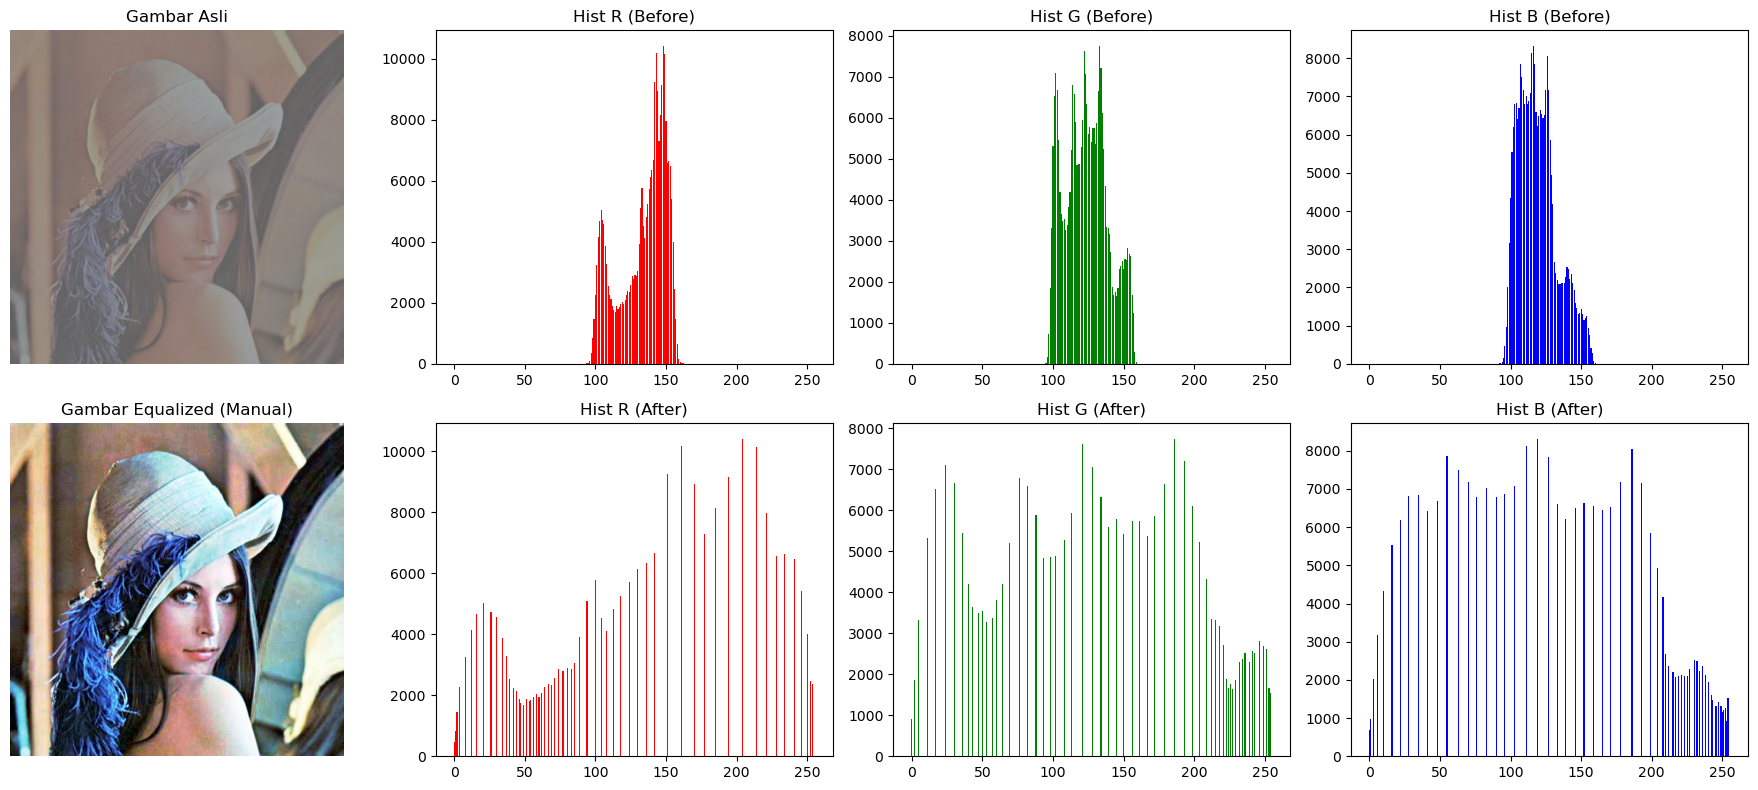

In [ ]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

img = cv.imread('../images/lena_lc.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

def hist_eq(channel):
    hist, bins = np.histogram(channel.flatten(), bins=256, range=[0,256])
    cdf = hist.cumsum()
    
    cdf_normalized = (cdf - cdf.min()) * 255 / (cdf.max() - cdf.min())
    cdf_normalized = cdf_normalized.astype('uint8')
    
    equalized_channel = cdf_normalized[channel]
    return equalized_channel, hist, cdf_normalized

r_eq, hist_r, cdf_r = hist_eq(img[:,:,0])
g_eq, hist_g, cdf_g = hist_eq(img[:,:,1])
b_eq, hist_b, cdf_b = hist_eq(img[:,:,2])

equalized_img = cv.merge((r_eq, g_eq, b_eq))

hist_r_eq, bins_r_eq = np.histogram(r_eq.flatten(), bins=256, range=[0,256])
hist_g_eq, bins_g_eq = np.histogram(g_eq.flatten(), bins=256, range=[0,256])
hist_b_eq, bins_b_eq = np.histogram(b_eq.flatten(), bins=256, range=[0,256])

fig, axs = plt.subplots(2, 4, figsize=(18,8))

axs[0,0].imshow(img)
axs[0,0].set_title("Gambar Asli")
axs[0,0].axis("off")

axs[0,1].bar(np.arange(256), hist_r, color='red')
axs[0,1].set_title("Hist R (Before)")
axs[0,2].bar(np.arange(256), hist_g, color='green')
axs[0,2].set_title("Hist G (Before)")
axs[0,3].bar(np.arange(256), hist_b, color='blue')
axs[0,3].set_title("Hist B (Before)")

axs[1,0].imshow(equalized_img)
axs[1,0].set_title("Gambar Equalized (Manual)")
axs[1,0].axis("off")

axs[1,1].bar(np.arange(256), hist_r_eq, color='red')
axs[1,1].set_title("Hist R (After)")
axs[1,2].bar(np.arange(256), hist_g_eq, color='green')
axs[1,2].set_title("Hist G (After)")
axs[1,3].bar(np.arange(256), hist_b_eq, color='blue')
axs[1,3].set_title("Hist B (After)")

plt.tight_layout()
plt.show()

### 2. Setelah mengerjakan langkah no. 1, buatlah histogram citra yang sama akan tetapi menggunakan library yang dimiliki oleh CV2 yaitu “equalizeHist” seperti pada potongan kode berikut ini.

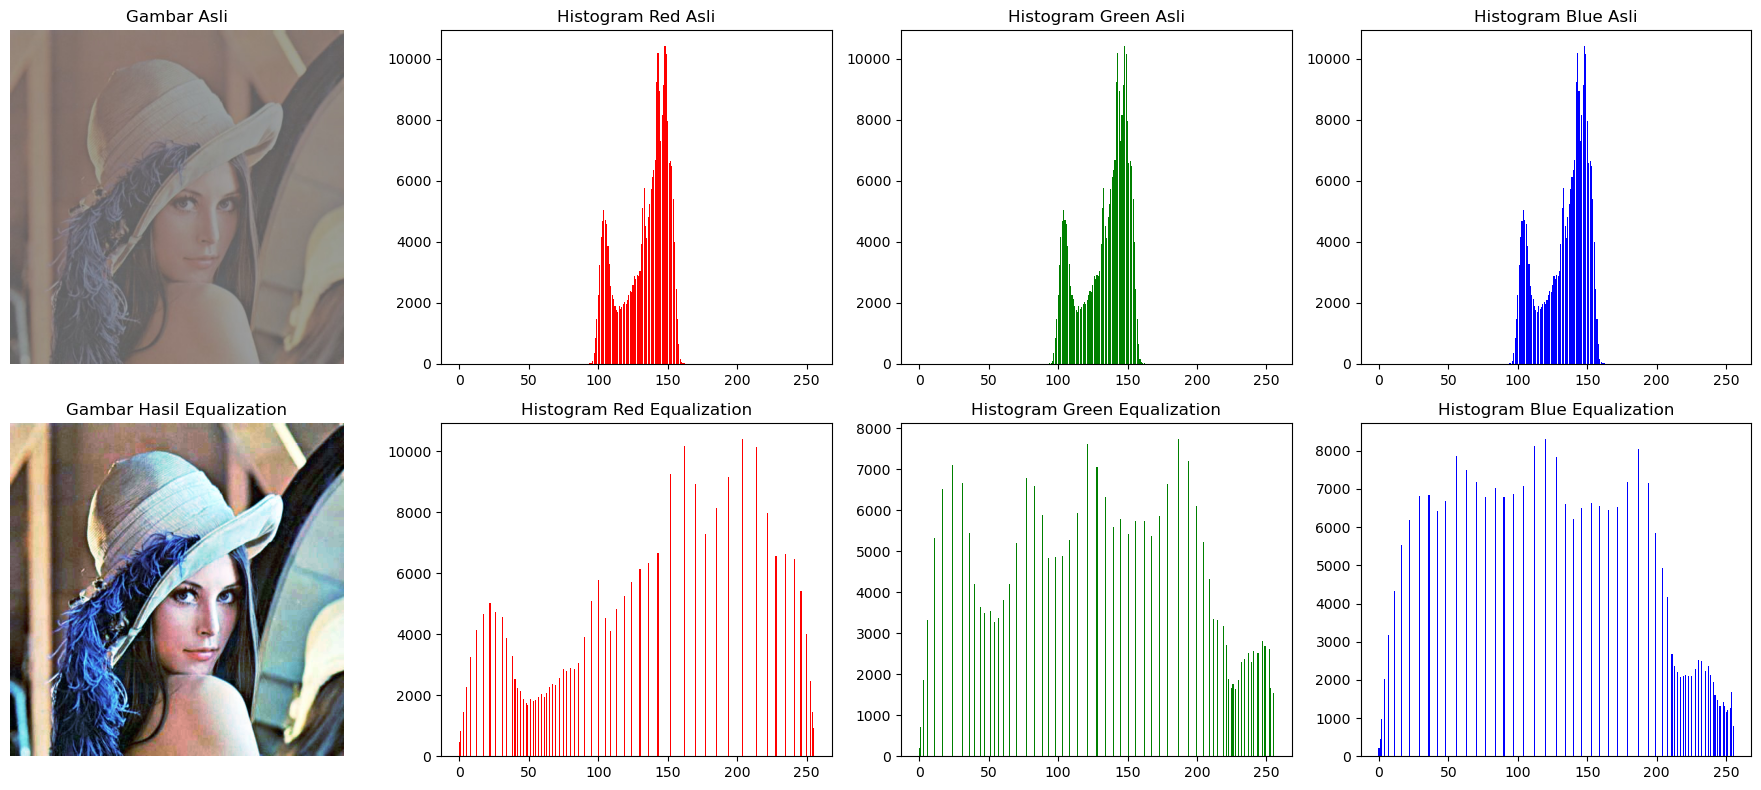

: 

In [ ]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

img = img = cv.imread('../images/lena_lc.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

r, g, b = cv.split(img)

r_eq = cv.equalizeHist(r)
g_eq = cv.equalizeHist(g)
b_eq = cv.equalizeHist(b)

img_eq = cv.merge((r_eq, g_eq, b_eq))

hist_r, bins_r = np.histogram(r.ravel(), 256, [0,256])
hist_g, bins_g = np.histogram(g.ravel(), 256, [0,256])
hist_b, bins_b = np.histogram(b.ravel(), 256, [0,256])

hist_r_eq, bins_r_eq = np.histogram(r_eq.ravel(), 256, [0,256])
hist_g_eq, bins_g_eq = np.histogram(g_eq.ravel(), 256, [0,256])
hist_b_eq, bins_b_eq = np.histogram(b_eq.ravel(), 256, [0,256])


fig, axs = plt.subplots(2, 4, figsize=(18,8))

axs[0,0].imshow(img)
axs[0,0].set_title("Gambar Asli")
axs[0,0].axis("off")

axs[0,1].bar(bins_r[:-1], hist_r, color='red')
axs[0,1].set_title("Histogram Red Asli")
axs[0,2].bar(bins_r[:-1], hist_r, color='green')
axs[0,2].set_title("Histogram Green Asli")
axs[0,3].bar(bins_r[:-1], hist_r, color='blue')
axs[0,3].set_title("Histogram Blue Asli")

axs[1,0].imshow(img_eq)
axs[1,0].set_title("Gambar Hasil Equalization")
axs[1,0].axis("off")

axs[1,1].bar(bins_r_eq[:-1], hist_r_eq, color='red')
axs[1,1].set_title("Histogram Red Equalization")
axs[1,2].bar(bins_g_eq[:-1], hist_g_eq, color='green')
axs[1,2].set_title("Histogram Green Equalization")
axs[1,3].bar(bins_b_eq[:-1], hist_b_eq, color='blue')    
axs[1,3].set_title("Histogram Blue Equalization")

plt.tight_layout()
plt.show()


**Jawaban:** Output sama baik dengan cara manual maupun dengan ```cv.equalizeHist()```

## PERTANYAAN PRAKTIKUM D2